In [1]:
import base64
import time
from io import BytesIO
from pathlib import Path

import ipywidgets as widgets
import markdown
import pypdfium2 as pdfium
from IPython.display import HTML, Image, display
from openai import OpenAI
from openai.types.chat import (
    ChatCompletionContentPartParam,
    ChatCompletionUserMessageParam,
)

MODEL_NAME = "unsloth/gemma-4-12b-it-GGUF:UD-Q8_K_XL"

client = OpenAI(base_url="http://127.0.0.1:8080/", api_key="api-keys-are-for-losers")

In [2]:
def collapsible(text, title="Reasoning"):
    html_content = markdown.markdown(text, extensions=["fenced_code", "codehilite"])

    styled_html = f"""
    <div style="
        background-color: #1e1e1e;
        color: #d4d4d4;
        padding: 12px;
        border-radius: 8px;
        font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', sans-serif;
        line-height: 1.5;
    ">
        {html_content}
    </div>
    """

    out = widgets.Output()
    with out:
        display(HTML(styled_html))

    accordion = widgets.Accordion(children=[out])
    accordion.set_title(0, title)

    display(accordion)

In [3]:
def predict(
    prompt: str,
    file_path: str | Path | None = None,
    max_pages: int | None = None,
) -> tuple[str, str]:
    t0_total = time.perf_counter()
    content: list[ChatCompletionContentPartParam] = [{"type": "text", "text": prompt}]

    if file_path is not None:
        file_path = Path(file_path)
        suffix = file_path.suffix.lower()

        if suffix == ".pdf":
            print(f"[*] Rasterizing '{file_path}' with pypdfium2...")
            t0_pdf = time.perf_counter()

            pdf = pdfium.PdfDocument(str(file_path))
            page_count = len(pdf)
            page_limit = page_count if max_pages is None else min(max_pages, page_count)

            try:
                for page_index in range(page_limit):
                    page = pdf.get_page(page_index)
                    try:
                        image = page.render(scale=1).to_pil()
                    finally:
                        page.close()

                    buffered = BytesIO()
                    image.save(buffered, format="JPEG", quality=90)
                    img_b64 = base64.b64encode(buffered.getvalue()).decode("utf-8")

                    content.append(
                        {
                            "type": "image_url",
                            "image_url": {"url": f"data:image/jpeg;base64,{img_b64}"},
                        }
                    )
            finally:
                pdf.close()

            t1_pdf = time.perf_counter()
            print(f"    -> PDF conversion took: {t1_pdf - t0_pdf:.2f} seconds.")
            print(f"    -> Prepared {page_limit} page image(s).")
        elif suffix in {".png", ".jpg", ".jpeg"}:
            print(f"[*] Loading image '{file_path}'...")
            t0_img = time.perf_counter()
            mime_type = "image/png" if suffix == ".png" else "image/jpeg"
            img_b64 = base64.b64encode(file_path.read_bytes()).decode("utf-8")
            content.append(
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime_type};base64,{img_b64}"},
                }
            )
            t1_img = time.perf_counter()
            print(f"    -> Image load took: {t1_img - t0_img:.2f} seconds.")
        else:
            raise ValueError(
                f"Unsupported file type: '{suffix}'. Expected .pdf, .png, .jpg, or .jpeg."
            )

    print("[*] Sending request to local LLM...")
    image_count = len(content) - 1
    if image_count > 0:
        print(f"    -> Found {image_count} image(s) to include in the request.")
    t0_llm = time.perf_counter()
    user_message: ChatCompletionUserMessageParam = {
        "role": "user",
        "content": content,
    }
    response = client.chat.completions.create(model=MODEL_NAME, messages=[user_message])
    t1_llm = time.perf_counter()
    print(f"    -> llama.cpp inference took: {t1_llm - t0_llm:.2f} seconds.")
    print(f"    -> Total latency: {t1_llm - t0_total:.2f} seconds.")

    usage = response.usage
    if usage:
        print("\n[*] Token Usage Metadata:")
        print(f"    -> Prompt Tokens:     {usage.prompt_tokens:,}")
        print(f"    -> Completion Tokens: {usage.completion_tokens:,}")
        print(f"    -> Total Tokens:      {usage.total_tokens:,}")
        print(
            f"    -> Speed:             {usage.completion_tokens / (t1_llm - t0_llm):.2f} output tokens/sec"
        )
    message = response.choices[0].message
    reasoning_content = getattr(message, "reasoning_content", None) or ""
    content_str = message.content or ""

    return reasoning_content, content_str

## First Test


In [4]:
prompt = """
I want to wash my car. The car wash is 50 meters away.  Should I walk or drive?
"""

reasoning, response = predict(prompt=prompt)

[*] Sending request to local LLM...
    -> llama.cpp inference took: 19.79 seconds.
    -> Total latency: 19.79 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     40
    -> Completion Tokens: 665
    -> Total Tokens:      705
    -> Speed:             33.60 output tokens/sec


In [5]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [6]:
print(response)

You should **walk**.

Here is why:

1.  **The Distance:** 50 meters is very short—it usually takes about one minute to walk that distance. 
2.  **Convenience:** It takes more effort to start the car, put it in gear, navigate, and find a parking spot than it does to simply walk 50 meters.
3.  **Cleanliness:** If your car is dirty enough to need a wash, driving it might just splash mud or dirt onto the road or other cars. 

**The only exceptions to walk would be:**
*   If it is currently pouring rain.
*   If it is dangerously hot outside.
*   If you have a physical mobility issue that makes walking difficult.

Otherwise, park the car and enjoy the quick stroll!


## SVG


In [7]:
prompt = """
Create SVG with a penguin, at the powerlifting rack and being ready to deadlift. Animate it. HTML only.
"""
reasoning, response = predict(prompt=prompt)

[*] Sending request to local LLM...
    -> llama.cpp inference took: 73.49 seconds.
    -> Total latency: 73.49 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     41
    -> Completion Tokens: 2,733
    -> Total Tokens:      2,774
    -> Speed:             37.19 output tokens/sec


In [8]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [9]:
print(response)

This is a single-file HTML solution. It uses an SVG for the graphics and CSS Keyframes to animate the penguin's "preparation" and "lift" sequence.

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Powerlifting Penguin</title>
    <style>
        body {
            display: flex;
            justify-content: center;
            align-items: center;
            height: 100vh;
            margin: 0;
            background-color: #f0f0f0;
            font-family: sans-serif;
        }

        .container {
            text-align: center;
        }

        svg {
            filter: drop-shadow(0px 10px 5px rgba(0,0,0,0.1));
        }

        /* Animation for the penguin and the bar */
        @keyframes lift-sequence {
            0%, 20% { 
                transform: translateY(0) scaleY(1); 
            }
            25% { 
                transform: translateY(-2px) scaleY(1.

## Meal Ideas


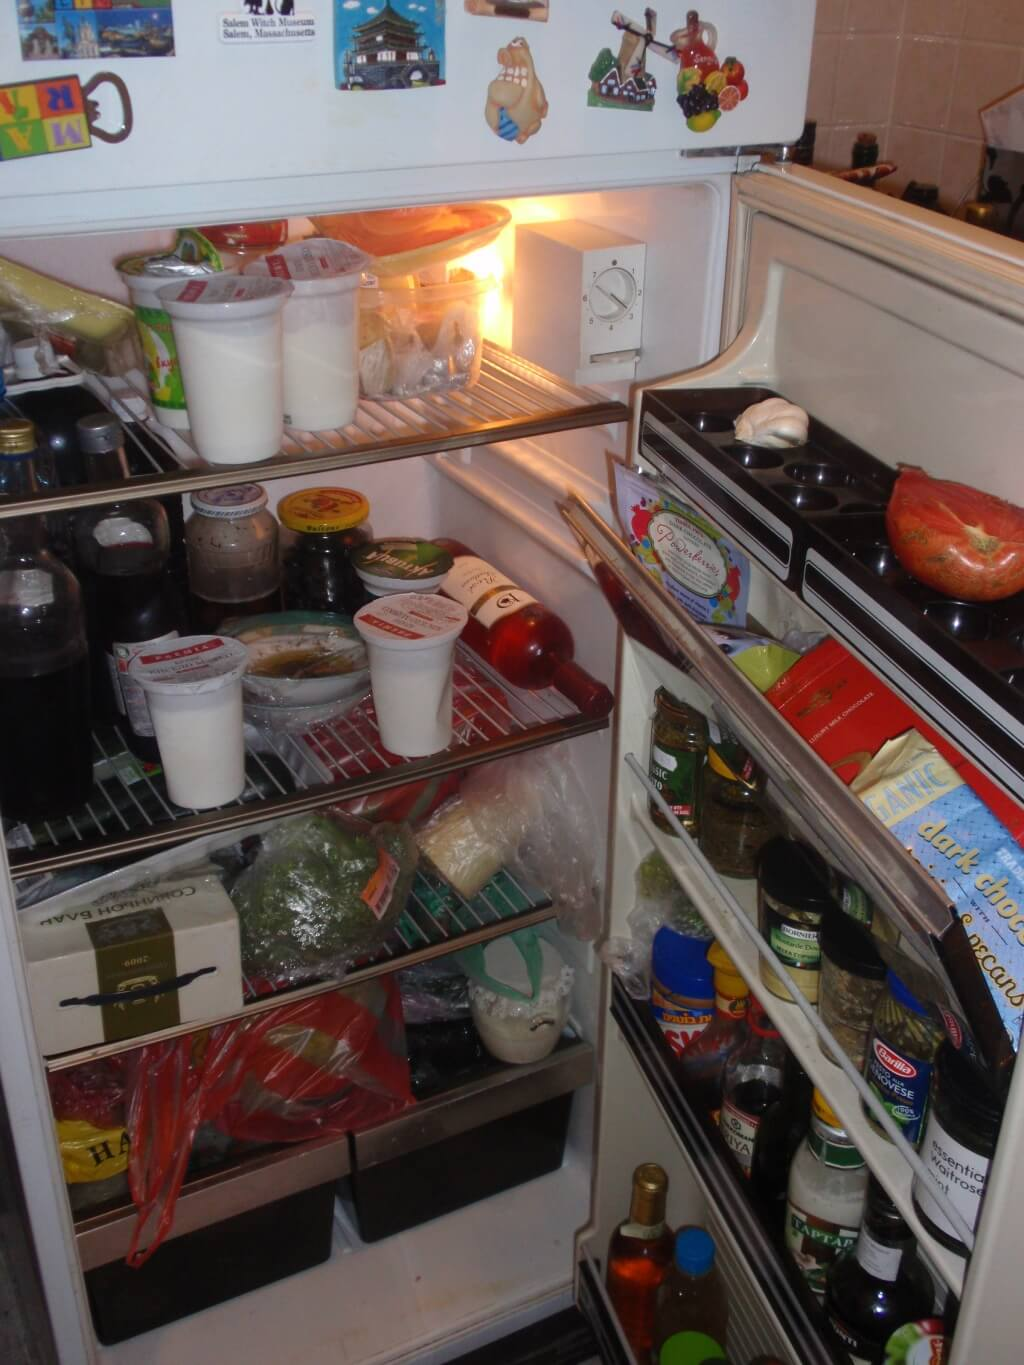

In [10]:
Image(filename="./assets/bulgarian-fridge.jpg", width=512)

In [11]:
prompt = """
You are an expert chef. Look at the ingredients inside my fridge.
1. List the main ingredients you can clearly identify.
2. Give me a step-by-step recipe for a quick, delicious meal I can make right now using ONLY what is in this picture.
Keep it practical and easy.
"""
reasoning, response = predict(prompt=prompt, file_path="./assets/bulgarian-fridge.jpg")

[*] Loading image 'assets/bulgarian-fridge.jpg'...
    -> Image load took: 0.00 seconds.
[*] Sending request to local LLM...
    -> Found 1 image(s) to include in the request.
    -> llama.cpp inference took: 56.41 seconds.
    -> Total latency: 56.41 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     349
    -> Completion Tokens: 1,869
    -> Total Tokens:      2,218
    -> Speed:             33.13 output tokens/sec


In [12]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [13]:
print(response)

Based on the contents of your fridge, here is the breakdown of what we have to work with and a delicious meal you can whip up quickly.

### 1. Main Ingredients Identified:
*   **Greens:** A large bag of fresh spinach.
*   **Base/Carbs:** A container of what appears to be rice or small grains (middle shelf).
*   **Dairy:** A box of cream cheese, plus several tubs of yogurt or sour cream.
*   **Produce:** Red peppers (bottom shelf) and a fresh apple (on top).
*   **Flavorings/Condiments:** Soy sauce, hot sauce, and various jars of preserves/spreads.

---

### 2. The Recipe: Creamy Spicy Spinach & Rice Bowl
Since you have a great mix of creamy elements, hearty greens, and savory sauces, we are going to make a **Savory Creamy Spinach & Rice Bowl**. It’s filling, fast, and uses the best textures in your fridge.

**Prep time:** 5 minutes | **Cook time:** 10 minutes

**Instructions:**

1.  **Prepare the Base:** Take the container of rice/grains and heat it up in a pan or microwave until warm.

## Web Design


In [14]:
prompt = """
Create a simple CV/resume website for ML/AI engineer. Use matrix-like vibe with minimalistic and techy-like vibe. 
Use simple and flat design for the whole app. Create a single HTML/JS/CSS file that would represent the whole website.
"""
reasoning, response = predict(prompt=prompt)

[*] Sending request to local LLM...
    -> llama.cpp inference took: 86.03 seconds.
    -> Total latency: 86.03 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     71
    -> Completion Tokens: 3,237
    -> Total Tokens:      3,308
    -> Speed:             37.63 output tokens/sec


In [15]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [16]:
print(response)

To achieve the **Matrix/Techy vibe** while keeping it **minimalist and flat**, I have designed a "Terminal-style" resume. 

Key features:
1.  **Matrix Rain Effect:** A subtle, low-opacity background animation.
2.  **Monospace Typography:** Uses standard coding fonts.
3.  **Flat UI:** No shadows, no gradients—just borders and high-contrast colors.
4.  **Single File:** Everything (HTML, CSS, JS) is contained in one block.

Copy the code below and save it as `index.html`.

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>ML_ENGINEER_CV // SYSTEM_OVERVIEW</title>
    <style>
        /* --- DESIGN SYSTEM --- */
        :root {
            --bg-color: #0a0a0a;
            --primary-green: #00ff41;
            --dark-green: #003b00;
            --text-gray: #d1d1d1;
            --border-style: 1px solid var(--primary-green);
            --font-main: 'Courier New', Courier, monospace

## Game Generation


In [17]:
prompt = """
Generate ultra realistic water in three.js with a boat on it and occasional waves hitting it, real physics. 
I want to be able to move the boat and have enemies trying to kill my boat. 
I should be able to move the boat with keyboard and aim with the mouse. The result should be a single HTML file.
"""
reasoning, response = predict(prompt=prompt)

[*] Sending request to local LLM...
    -> llama.cpp inference took: 106.35 seconds.
    -> Total latency: 106.35 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     85
    -> Completion Tokens: 3,969
    -> Total Tokens:      4,054
    -> Speed:             37.32 output tokens/sec


In [18]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [19]:
print(response)

To create an "ultra-realistic" water effect in a single HTML file using Three.js, we need to use **Custom Shaders (GLSL)**. Standard materials won't provide the wave movement or the "bobbing" physics required.

Because this is a single file, I have implemented:
1.  **Gerstner Wave Shader:** For realistic moving water surface.
2.  **Buoyancy Physics:** The boat's height and tilt are calculated based on the water's height at its specific coordinates.
3.  **Enemy AI:** Simple "seek" behavior where enemies move toward you.
4.  **Pointer Lock:** Click the screen to lock your mouse for 3D aiming.

```html
<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Ocean Combat - Three.js</title>
    <style>
        body { margin: 0; overflow: hidden; background-color: #000; font-family: sans-serif; }
        #ui {
            position: absolute; top: 20px; left: 20px; color: white;
            pointe

## Receipts


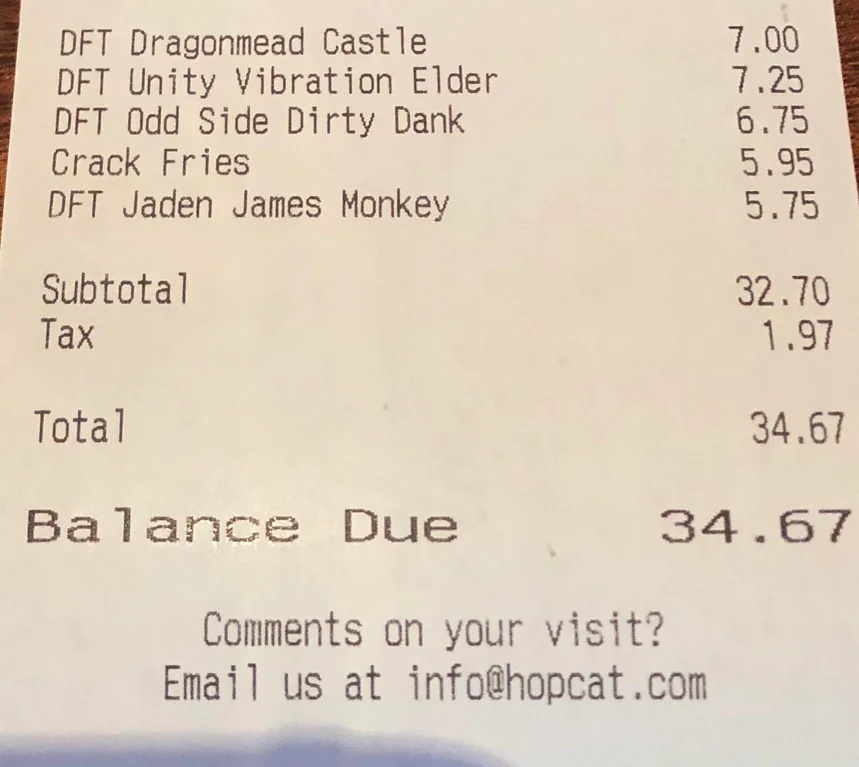

In [20]:
Image(filename="./assets/receipts/naughty.jpg", width=512)

In [21]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

reasoning, response = predict(prompt=prompt, file_path="./assets/receipts/naughty.jpg")

[*] Loading image 'assets/receipts/naughty.jpg'...
    -> Image load took: 0.00 seconds.
[*] Sending request to local LLM...
    -> Found 1 image(s) to include in the request.
    -> llama.cpp inference took: 25.31 seconds.
    -> Total latency: 25.31 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     296
    -> Completion Tokens: 1,023
    -> Total Tokens:      1,319
    -> Speed:             40.41 output tokens/sec


In [22]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [23]:
print(response)

```json
{
  "merchant": "Hopcat",
  "date": null,
  "line_items": [
    {
      "item": "DFT Dragonmead Castle",
      "price": 7.00
    },
    {
      "item": "DFT Unity Vibration Elder",
      "price": 7.25
    },
    {
      "item": "DFT Odd Side Dirty Dank",
      "price": 6.75
    },
    {
      "item": "Crack Fries",
      "price": 5.95
    },
    {
      "item": "DFT Jaden James Monkey",
      "price": 5.75
    }
  ],
  "subtotal": 32.70,
  "tax": 1.97,
  "total": 34.67
}
```


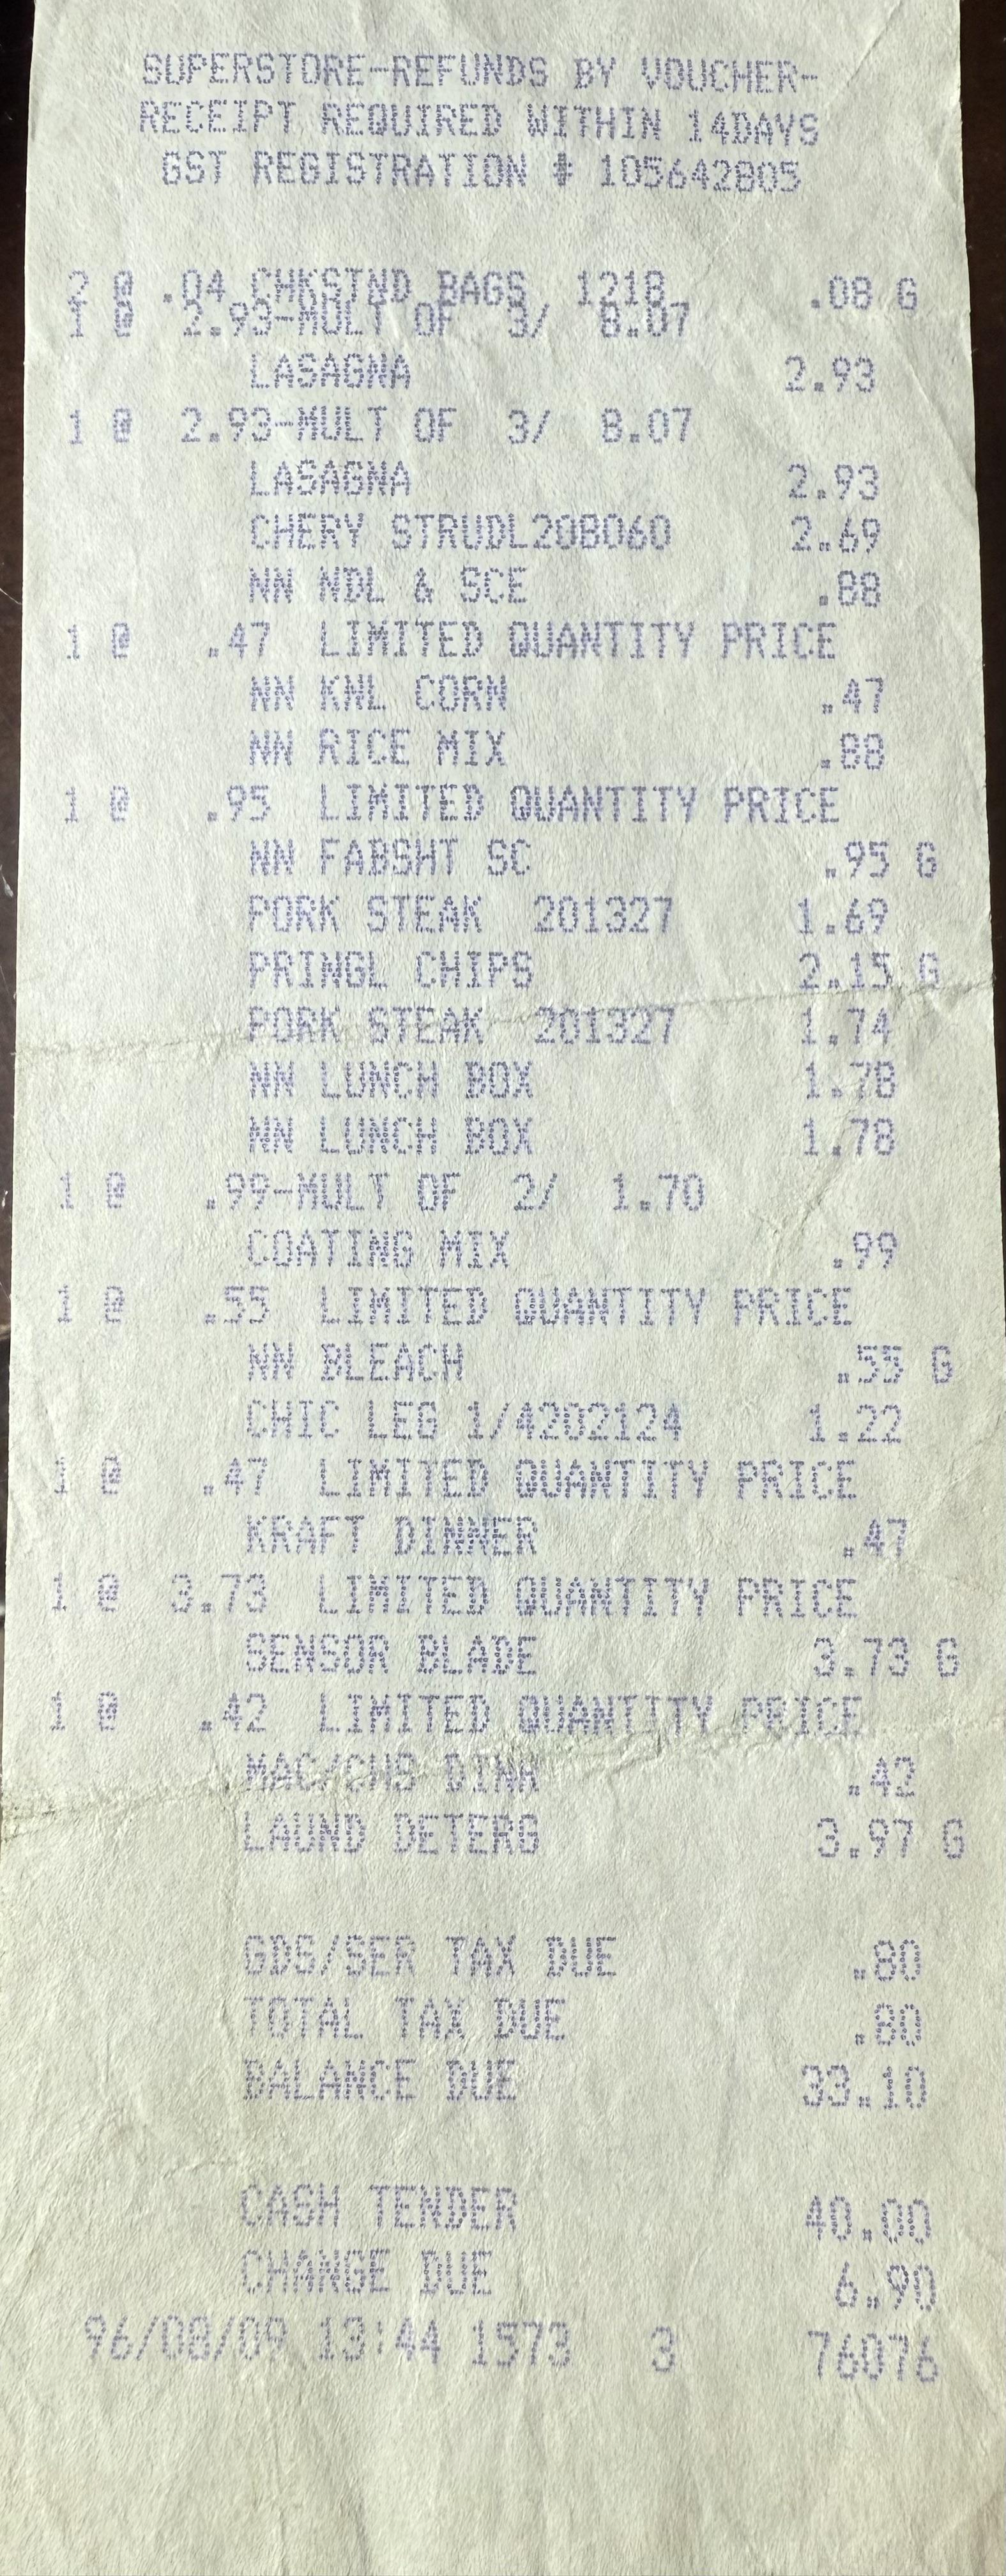

In [24]:
Image(filename="./assets/receipts/old.jpeg", width=512)

In [25]:
prompt = """
Extract all text from this receipt. Return line items, total, tax, merchant, and date as JSON.
"""

reasoning, response = predict(prompt=prompt, file_path="./assets/receipts/old.jpeg")

[*] Loading image 'assets/receipts/old.jpeg'...
    -> Image load took: 0.00 seconds.
[*] Sending request to local LLM...
    -> Found 1 image(s) to include in the request.
    -> llama.cpp inference took: 433.87 seconds.
    -> Total latency: 433.87 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     301
    -> Completion Tokens: 15,637
    -> Total Tokens:      15,938
    -> Speed:             36.04 output tokens/sec


In [26]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [27]:
print(response)

```json
{
  "merchant": "SUPERSTORE",
  "date": "96/08/09",
  "line_items": [
    {
      "item": "SKINTON BAGS 1218",
      "price": 0.08
    },
    {
      "item": "LASAGNA (MULT OF 3 / 8.07)",
      "price": 2.93
    },
    {
      "item": "LASAGNA",
      "price": 2.93
    },
    {
      "item": "LASAGNA (MULT OF 3 / 8.07)",
      "price": 2.93
    },
    {
      "item": "LASAGNA",
      "price": 2.93
    },
    {
      "item": "CHERY STRUDL2B0060",
      "price": 2.69
    },
    {
      "item": "NN RICE MIX",
      "price": 0.88
    },
    {
      "item": "NN KNL CORN",
      "price": 0.47
    },
    {
      "item": "NN RICE MIX",
      "price": 0.88
    },
    {
      "item": "NN FASHI",
      "price": 0.95
    },
    {
      "item": "PORK STEAK 201327",
      "price": 1.69
    },
    {
      "item": "PRINCE CHIPS",
      "price": 2.15
    },
    {
      "item": "PORK STEAK 201327",
      "price": 1.74
    },
    {
      "item": "NN LUNCH BOX",
      "price": 1.78
    },
    {
  

## Financial Docs


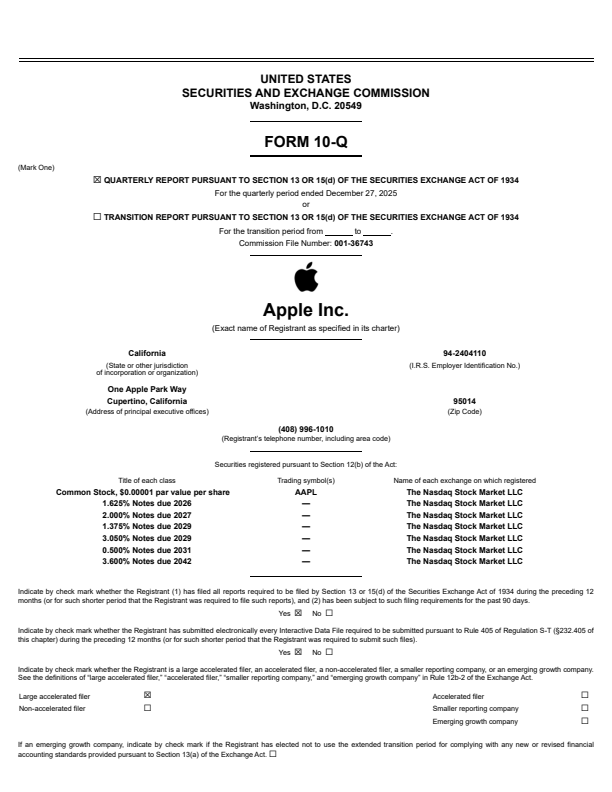

In [28]:
pdf = pdfium.PdfDocument(str("./assets/financial/apple-q1-2026.pdf"))
page = pdf.get_page(0)
image = page.render(scale=1).to_pil()
pdf.close()
image

In [29]:
prompt = """
Extract the specified data from the financial document. 
Return the company name, form type and company ticker as JSON.
"""

reasoning, response = predict(
    prompt=prompt, file_path="./assets/financial/apple-q1-2026.pdf"
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.03 seconds.
    -> Prepared 8 page image(s).
[*] Sending request to local LLM...
    -> Found 8 image(s) to include in the request.
    -> llama.cpp inference took: 8.50 seconds.
    -> Total latency: 8.52 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     1,825
    -> Completion Tokens: 170
    -> Total Tokens:      1,995
    -> Speed:             20.01 output tokens/sec


In [30]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [31]:
print(response)

```json
{
  "company name": "Apple Inc.",
  "form type": "FORM 10-Q",
  "company ticker": "AAPL"
}
```


In [32]:
prompt = """
Extract the specified data from the financial document. 
Return the Note 2 - Revenue table as Markdown.
"""

reasoning, response = predict(
    prompt=prompt, file_path="./assets/financial/apple-q1-2026.pdf"
)

[*] Rasterizing 'assets/financial/apple-q1-2026.pdf' with pypdfium2...
    -> PDF conversion took: 0.03 seconds.
    -> Prepared 8 page image(s).
[*] Sending request to local LLM...
    -> Found 8 image(s) to include in the request.
    -> llama.cpp inference took: 32.98 seconds.
    -> Total latency: 33.01 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     1,823
    -> Completion Tokens: 1,140
    -> Total Tokens:      2,963
    -> Speed:             34.56 output tokens/sec


In [33]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [34]:
print(response)

### Note 2 - Revenue
(in millions)

| Three Months Ended | December 27, 2023 | December 28, 2024 |
| :--- | :--- | :--- |
| Products | $85,204 | $86,139 |
| Mac | $8,366 | $8,887 |
| iPad | $6,200 | $6,184 |
| Wearables, Home, and Accessories | $11,463 | $11,747 |
| **Total net sales** | **$143,735** | **$124,303** |
| Portion of total net sales that was included in deferred revenue at the beginning of the period | $4,056 | $3,866 |


| Three Months Ended                                                                              | December 27, 2023 | December 28, 2024 |
| :---------------------------------------------------------------------------------------------- | :---------------- | :---------------- |
| Products                                                                                        | $85,204           | $86,139           |
| Mac                                                                                             | $8,366            | $8,887            |
| iPad                                                                                            | $6,200            | $6,184            |
| Wearables, Home, and Accessories                                                                | $11,463           | $11,747           |
| **Total net sales**                                                                             | **$143,735**      | **$124,303**      |
| Portion of total net sales that was included in deferred revenue at the beginning of the period | $4,056            | $3,866            |


In [ ]:
prompt = """
Extract the specified data from the financial document. 
Return the condensed consolidated balance sheets table as Markdown.
"""

reasoning, response = predict(
    prompt=prompt, file_path="./assets/financial/nvidia-q3-2025-press-release.pdf"
)

In [ ]:
collapsible(reasoning)

In [ ]:
print(response)

In [ ]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
reasoning, response = predict(
    prompt=prompt, file_path="./assets/papers/simple-self-distillation-excerpt.pdf"
)

In [ ]:
collapsible(reasoning)

In [ ]:
print(response)

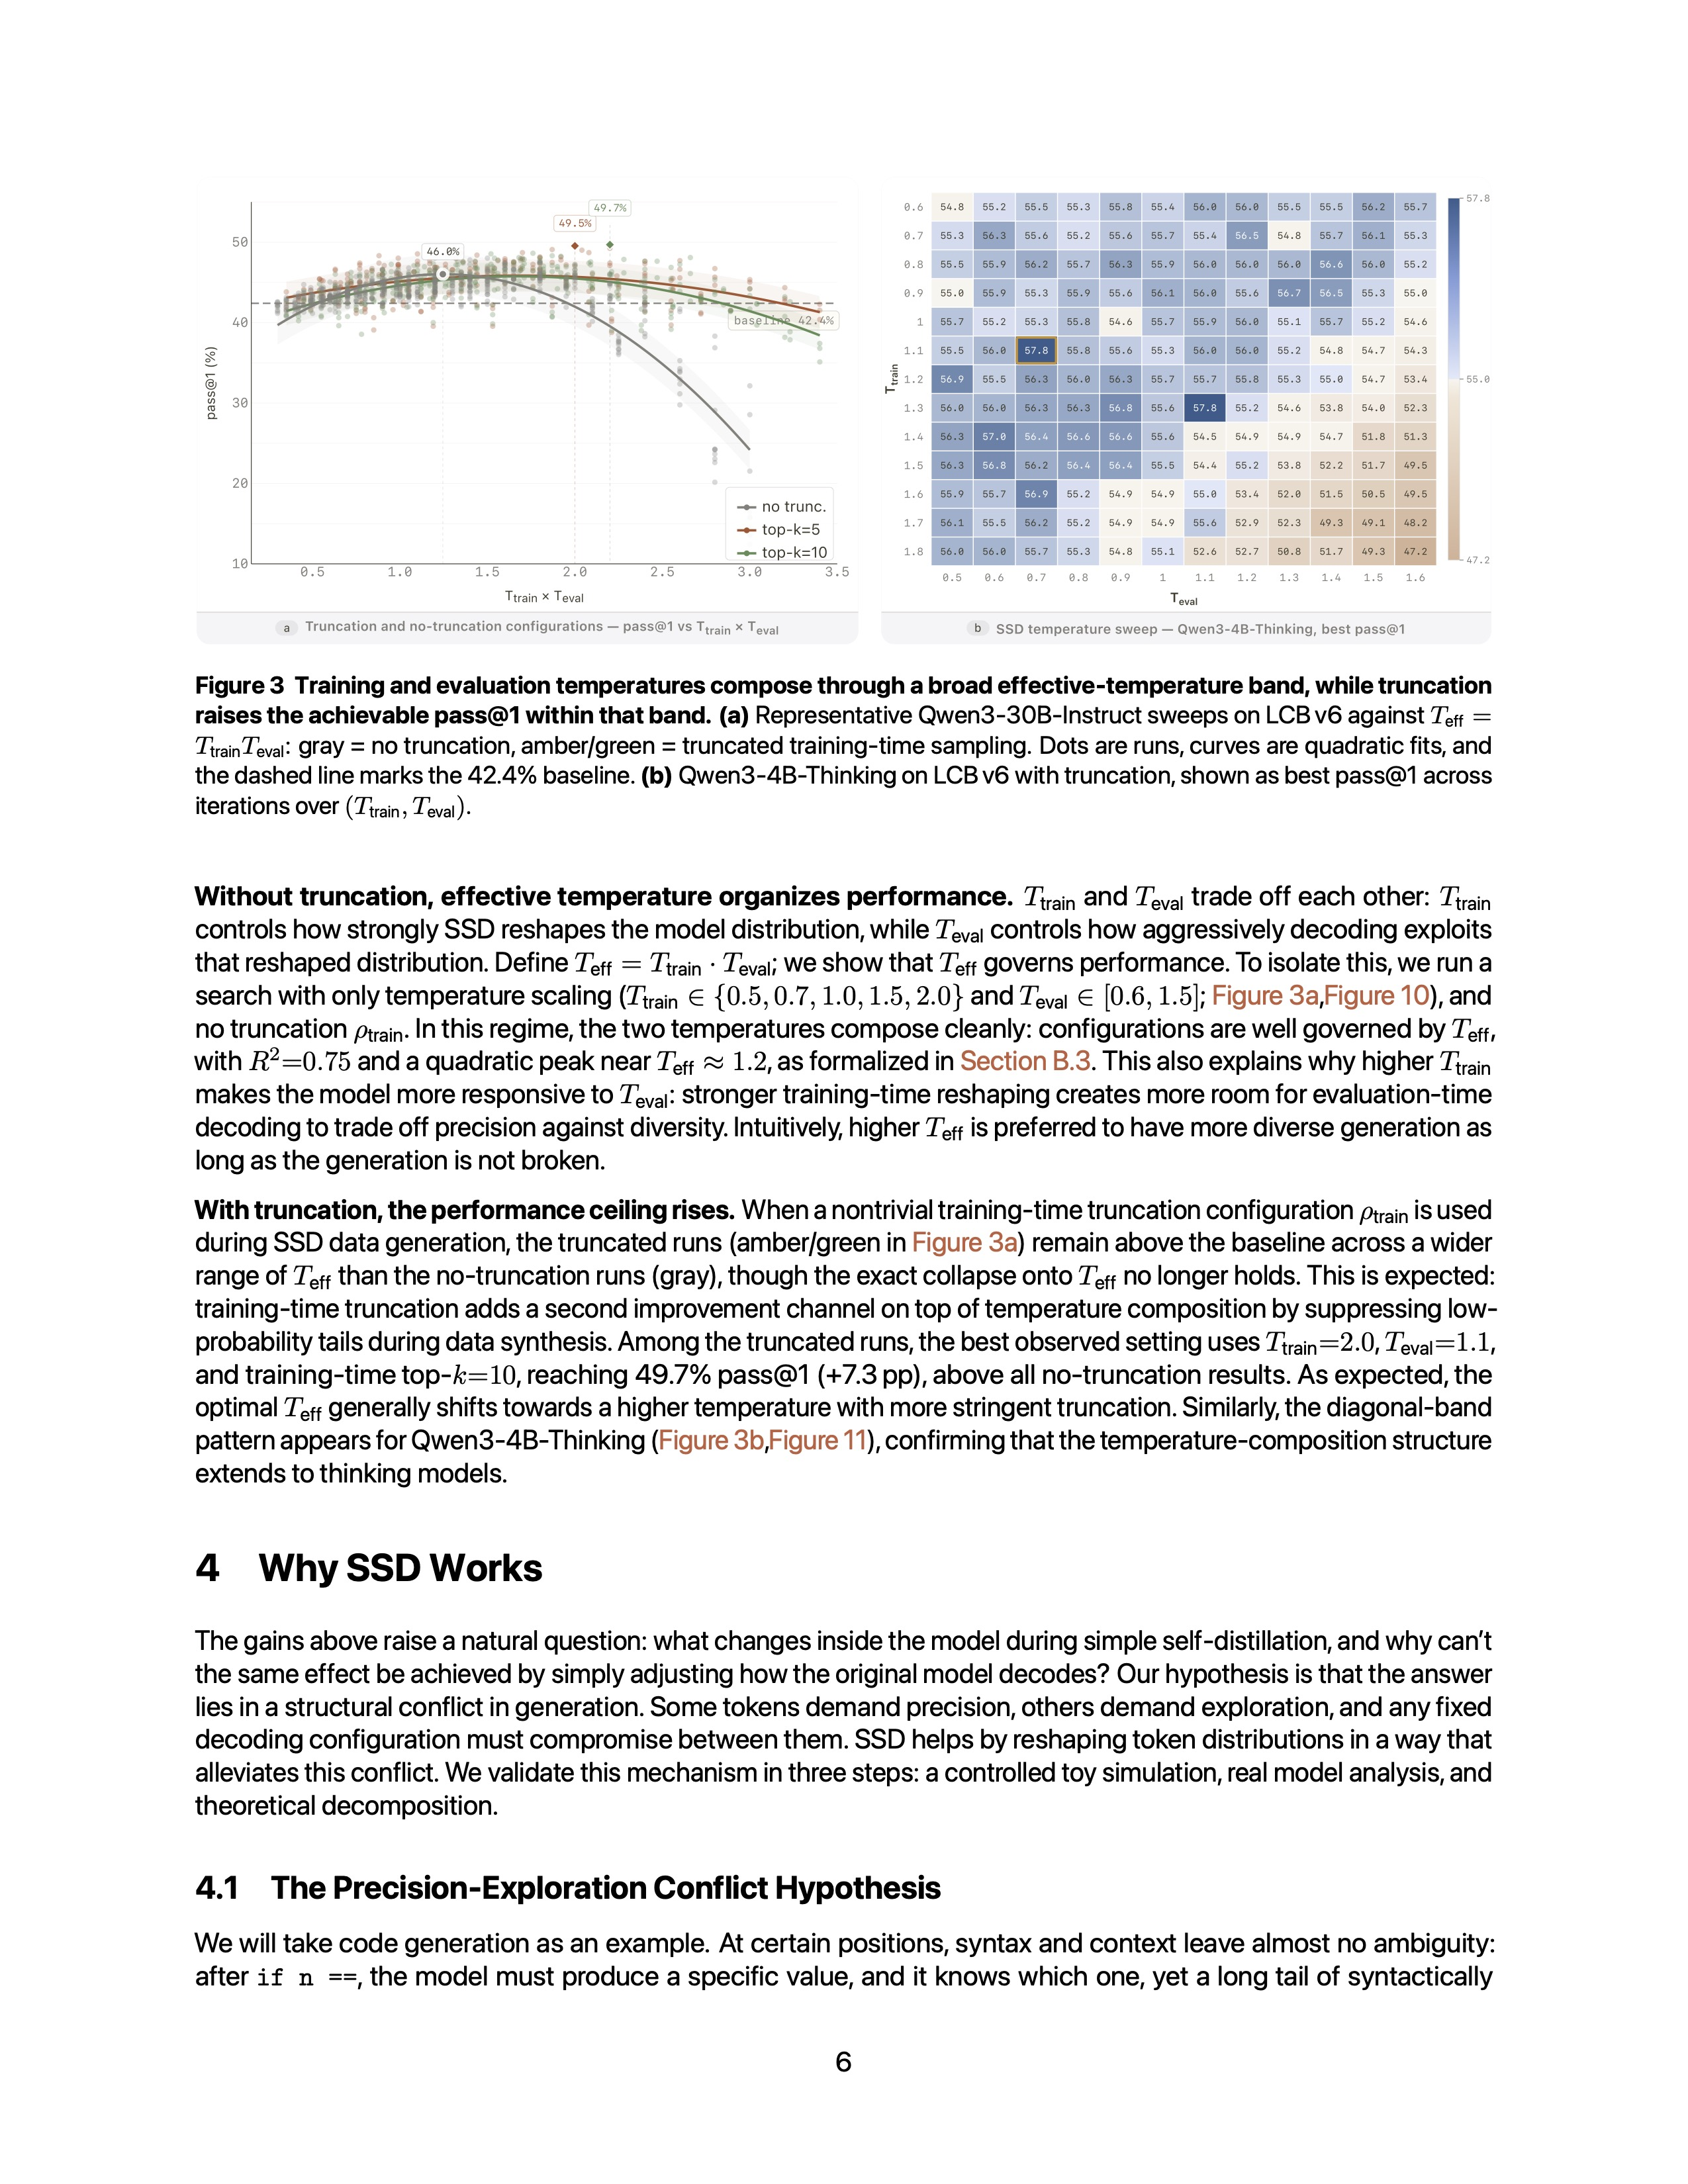

In [37]:
Image(filename="./assets/papers/single-page.jpg", width=512)

In [38]:
prompt = """
Extract the specified data from the research paper. 
From the SSD temperature sweep table, extract the value at 
Teval 1.2 and Ttrain 0.9.
"""

# 55.6
reasoning, response = predict(
    prompt=prompt, file_path="./assets/papers/single-page.jpg"
)

[*] Loading image 'assets/papers/single-page.jpg'...
    -> Image load took: 0.00 seconds.
[*] Sending request to local LLM...
    -> Found 1 image(s) to include in the request.
    -> llama.cpp inference took: 11.31 seconds.
    -> Total latency: 11.31 seconds.

[*] Token Usage Metadata:
    -> Prompt Tokens:     323
    -> Completion Tokens: 421
    -> Total Tokens:      744
    -> Speed:             37.23 output tokens/sec


In [39]:
collapsible(reasoning)

Accordion(children=(Output(),), titles=('Reasoning',))

In [40]:
print(response)

Based on the SSD temperature sweep table (Table 2) in the research paper, the value at $T_{eval} = 1.2$ and $T_{train} = 0.9$ is **2.1**.
